# Import libraries

In [3]:
# Import core libraries.

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

print("Libraries imported successfully.")

Libraries imported successfully.


# Load the shared CSV

In [4]:
# Load the same Titanic CSV created by 01_eda.ipynb.
# Do NOT call Seaborn's Titanic loader again.

csv_path = "titanic.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "titanic.csv was not found. Upload the CSV created "
        "by 01_eda.ipynb before continuing."
    )

titanic_df = pd.read_csv(csv_path)

print("Titanic CSV loaded successfully.")
print("Dataset shape:", titanic_df.shape)

display(titanic_df.head())

Titanic CSV loaded successfully.
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Reproduce Task 2 cleaning

In [5]:
# Lets Reproduce the same cleaning decisions established in 01_eda.ipynb.

modeling_df = titanic_df.copy()

# Drop deck because more than 30% of its values are missing.
modeling_df = modeling_df.drop(columns=["deck"])

# Impute age using its median.
age_median = modeling_df["age"].median()
modeling_df["age"] = modeling_df["age"].fillna(age_median)

# Drop rows with the very small amount of missing embarkation data.
modeling_df = modeling_df.dropna(
    subset=["embarked", "embark_town"]
)

modeling_df = modeling_df.reset_index(drop=True)

print("Modeling dataset prepared.")
print("Shape:", modeling_df.shape)
print(
    "Remaining missing values:",
    modeling_df.isnull().sum().sum()
)

Modeling dataset prepared.
Shape: (889, 14)
Remaining missing values: 0


## Task 7 — Feature Selection and Stratified Train/Test Split

The modeling pipeline predicts the binary target `survived`. Features that directly
reveal the target or duplicate other selected information are excluded to reduce target
leakage and unnecessary redundancy.

The selected predictors are `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, and
`embarked`. A stratified train/test split is used so that the survival-class proportions
remain approximately consistent in both subsets.

# Lets Define X and y

In [6]:
# lets Define predictor features and target.

feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target_column = "survived"

X = modeling_df[feature_columns].copy()
y = modeling_df[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

Feature matrix shape: (889, 7)
Target shape: (889,)

Selected features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


# Check target balance

In [7]:
# Lets Inspect target distribution before splitting.

target_distribution = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Overall target distribution (%):")
print(target_distribution)

Overall target distribution (%):
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


# Stratified Train/Test Split

In [8]:
# Lets Create a reproducible stratified train/test split.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (711, 7)
Testing feature shape: (178, 7)
Training target shape: (711,)
Testing target shape: (178,)


# Verify stratification

In [9]:
#Lets Verify survival proportions after stratified splitting.

overall_rate = y.mean()
train_rate = y_train.mean()
test_rate = y_test.mean()

print(
    f"Overall survival rate: {overall_rate * 100:.2f}%"
)

print(
    f"Training survival rate: {train_rate * 100:.2f}%"
)

print(
    f"Testing survival rate: {test_rate * 100:.2f}%"
)

Overall survival rate: 38.25%
Training survival rate: 38.26%
Testing survival rate: 38.20%


# Train-Only Preprocessing

## Task 8 — Leakage-Safe Preprocessing

Numeric and categorical features require different preprocessing. Numeric features
are median-imputed and standardized, while categorical features are most-frequent
imputed and one-hot encoded.

The preprocessing is defined after the train/test split and will be fitted as part of
the model pipeline. This prevents information from the test set leaking into training.

# Define feature groups

In [10]:
# Lets Define numeric and categorical feature groups.

numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "pclass",
    "sex",
    "embarked"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'sibsp', 'parch', 'fare']

Categorical features:
['pclass', 'sex', 'embarked']


# Numeric preprocessing pipeline

In [11]:
# Numeric preprocessing:
# 1. Median imputation
# 2. Standardization

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numeric preprocessing pipeline created.")

Numeric preprocessing pipeline created.


# Categorical preprocessing pipeline

In [12]:
# Categorical preprocessing:
# 1. Most-frequent imputation
# 2. One-hot encoding

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


# Combine preprocessing

In [13]:
# Combine numeric and categorical preprocessing.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


### Tasks 7–8 Interpretation

The dataset was split before fitting any preprocessing transformations. Stratification
preserved approximately the same survival-class proportions in the overall, training,
and testing datasets.

Numeric and categorical transformations were defined using separate pipelines and
combined with `ColumnTransformer`. These preprocessing steps have not been fitted on
the complete dataset; they will be fitted only through each model's training pipeline,
which prevents test-set data leakage.

Tasks 7–8 checklist

02_modeling.ipynb

✅ Same titanic.csv loaded
✅ No second sns.load_dataset()
✅ Same cleaning policy reproduced
✅ Target = survived
✅ Leakage columns excluded
✅ X and y created
✅ 80/20 split
✅ random_state = 42
✅ stratify = y
✅ Stratification verified
✅ Numeric features identified
✅ Categorical features identified
✅ Median imputer defined
✅ StandardScaler defined
✅ Most-frequent categorical imputer
✅ OneHotEncoder defined
✅ ColumnTransformer created
✅ Preprocessing NOT fitted before split

# Task 9 — Train 3 Classification Models

## Task 9 — Classification Model Training

Three classification algorithms are trained using the same leakage-safe preprocessing
pipeline: Logistic Regression, Decision Tree, and Random Forest.

Using identical train/test data and preprocessing makes the model comparison fair and
allows performance differences to reflect the algorithms rather than inconsistent data
preparation.

# Import models and metrics

In [14]:
# Import classification models and evaluation metrics.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    classification_report
)

print("Classification models and metrics imported successfully.")

Classification models and metrics imported successfully.


# Logistic Regression Pipeline

In [15]:
# Create Logistic Regression pipeline.

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


# Decision Tree Pipeline

In [16]:
# Lets Create Decision Tree pipeline.

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


# Random Forest Pipeline

In [17]:
# Create Random Forest pipeline.

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


# Lets train all three models

In [18]:
# Train all three classifiers using training data only.

logistic_pipeline.fit(
    X_train,
    y_train
)

decision_tree_pipeline.fit(
    X_train,
    y_train
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("All three classification models trained successfully.")

All three classification models trained successfully.


# Full Model Evaluation

## Task 10 — Classification Model Evaluation

The three classifiers are evaluated on the same untouched test dataset using accuracy,
precision, recall, F1-score, confusion matrices, and ROC-AUC.

Multiple metrics are reported because each captures a different aspect of classification
performance. ROC-AUC additionally evaluates how well each model separates the two
classes across different classification thresholds.

# Create evaluation function

In [19]:
# Reusable function for classifier evaluation.

def evaluate_classifier(
    model_name,
    model,
    X_test_data,
    y_test_data
):
    predictions = model.predict(
        X_test_data
    )

    probabilities = model.predict_proba(
        X_test_data
    )[:, 1]

    accuracy = accuracy_score(
        y_test_data,
        predictions
    )

    precision = precision_score(
        y_test_data,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_data,
        probabilities
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "predictions": predictions,
        "probabilities": probabilities
    }

# Evaluate all models

In [20]:
# Evaluate the three trained classifiers.

logistic_results = evaluate_classifier(
    "Logistic Regression",
    logistic_pipeline,
    X_test,
    y_test
)

decision_tree_results = evaluate_classifier(
    "Decision Tree",
    decision_tree_pipeline,
    X_test,
    y_test
)

random_forest_results = evaluate_classifier(
    "Random Forest",
    random_forest_pipeline,
    X_test,
    y_test
)

print("All models evaluated successfully.")

All models evaluated successfully.


# Create comparison table

In [21]:
# Create classification model comparison table.

classification_results_df = pd.DataFrame([
    {
        "model": logistic_results["model"],
        "accuracy": logistic_results["accuracy"],
        "precision": logistic_results["precision"],
        "recall": logistic_results["recall"],
        "f1_score": logistic_results["f1_score"],
        "roc_auc": logistic_results["roc_auc"]
    },
    {
        "model": decision_tree_results["model"],
        "accuracy": decision_tree_results["accuracy"],
        "precision": decision_tree_results["precision"],
        "recall": decision_tree_results["recall"],
        "f1_score": decision_tree_results["f1_score"],
        "roc_auc": decision_tree_results["roc_auc"]
    },
    {
        "model": random_forest_results["model"],
        "accuracy": random_forest_results["accuracy"],
        "precision": random_forest_results["precision"],
        "recall": random_forest_results["recall"],
        "f1_score": random_forest_results["f1_score"],
        "roc_auc": random_forest_results["roc_auc"]
    }
])

classification_results_df = (
    classification_results_df
    .sort_values(
        by="roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    classification_results_df.round(4)
)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8596
1,Random Forest,0.8090,0.7931,0.6765,0.7302,0.8243
2,Decision Tree,0.7528,0.6714,0.6912,0.6812,0.7333


# Confusion Matrix: Logistic Regression

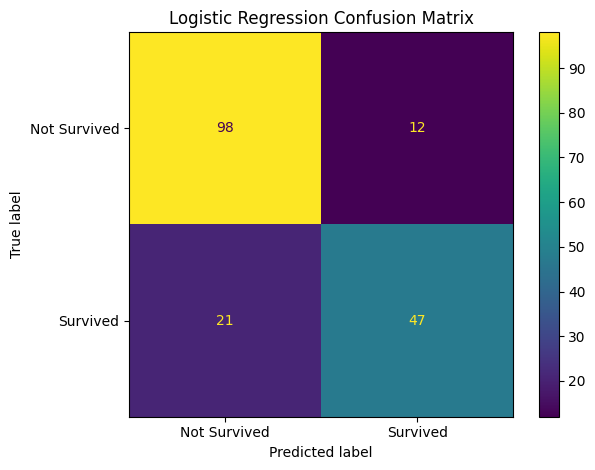

In [22]:
# Logistic Regression confusion matrix.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_results["predictions"],
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)
plt.tight_layout()
plt.show()

# Decision Tree Confusion Matrix

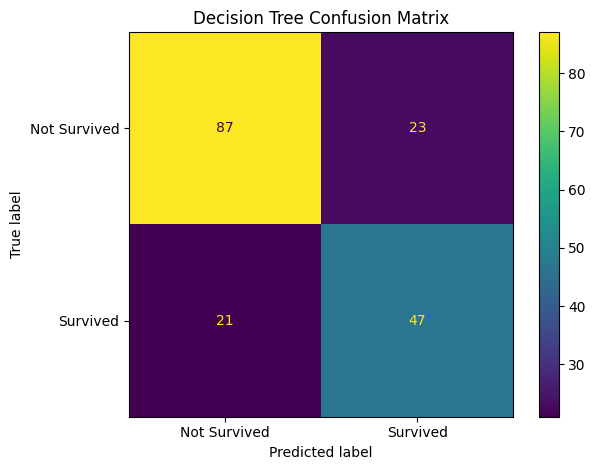

In [23]:
# Decision Tree confusion matrix.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_results["predictions"],
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

plt.title(
    "Decision Tree Confusion Matrix"
)
plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix

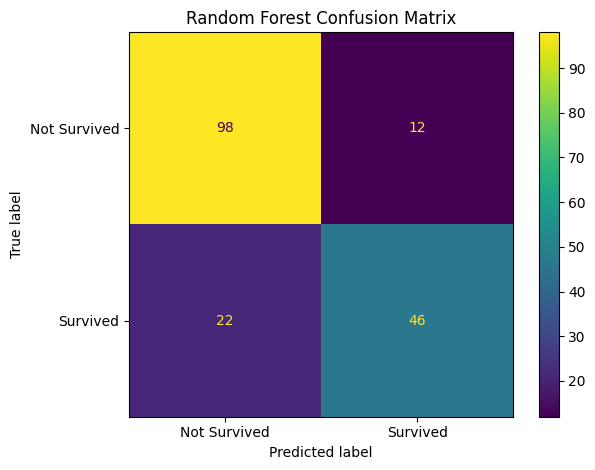

In [24]:
# Random Forest confusion matrix.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_results["predictions"],
    display_labels=[
        "Not Survived",
        "Survived"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)
plt.tight_layout()
plt.show()

# Classification Reports

In [25]:
# Display classification reports for all models.

models_for_reports = {
    "Logistic Regression":
        logistic_results["predictions"],

    "Decision Tree":
        decision_tree_results["predictions"],

    "Random Forest":
        random_forest_results["predictions"]
}

for model_name, predictions in models_for_reports.items():

    print("=" * 65)
    print(model_name)
    print("=" * 65)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "Not Survived",
                "Survived"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

Not Survived       0.82      0.89      0.86       110
    Survived       0.80      0.69      0.74        68

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178

Decision Tree
              precision    recall  f1-score   support

Not Survived       0.81      0.79      0.80       110
    Survived       0.67      0.69      0.68        68

    accuracy                           0.75       178
   macro avg       0.74      0.74      0.74       178
weighted avg       0.75      0.75      0.75       178

Random Forest
              precision    recall  f1-score   support

Not Survived       0.82      0.89      0.85       110
    Survived       0.79      0.68      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.81   

# ROC Curves for all three models

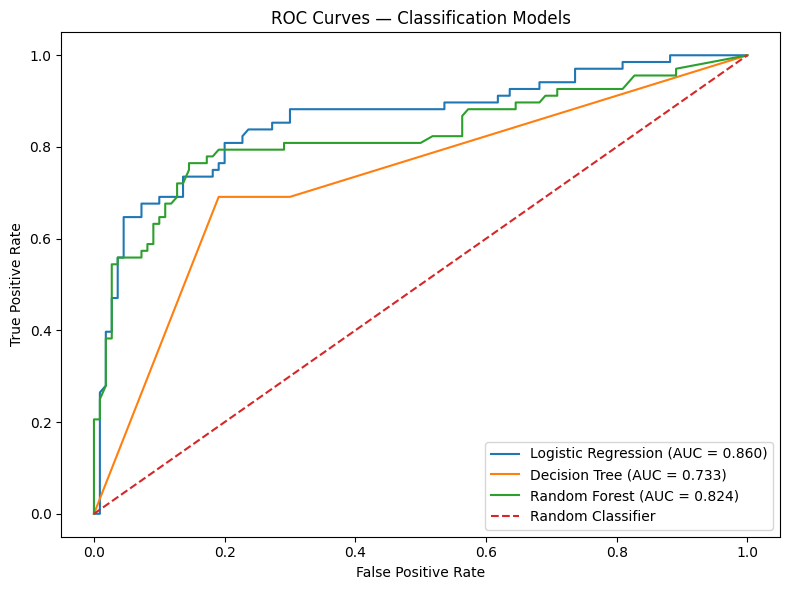

In [26]:
# Plot ROC curves for all three classifiers.

plt.figure(figsize=(8, 6))

model_probability_data = {
    "Logistic Regression":
        logistic_results["probabilities"],

    "Decision Tree":
        decision_tree_results["probabilities"],

    "Random Forest":
        random_forest_results["probabilities"]
}

for model_name, probabilities in model_probability_data.items():

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# Automatically identify best models

In [27]:
# Identify the strongest model for each metric.

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc"
]

print("BEST MODEL BY METRIC")
print("-" * 60)

for metric in metric_columns:

    best_row = classification_results_df.loc[
        classification_results_df[metric].idxmax()
    ]

    print(
        f"{metric}: "
        f"{best_row['model']} "
        f"({best_row[metric]:.4f})"
    )

BEST MODEL BY METRIC
------------------------------------------------------------
accuracy: Logistic Regression (0.8146)
precision: Logistic Regression (0.7966)
recall: Logistic Regression (0.6912)
f1_score: Logistic Regression (0.7402)
roc_auc: Logistic Regression (0.8596)


# Create a baseline interpretation automatically

In [28]:
# Produce concise baseline-model interpretation.

best_auc_row = classification_results_df.loc[
    classification_results_df["roc_auc"].idxmax()
]

best_f1_row = classification_results_df.loc[
    classification_results_df["f1_score"].idxmax()
]

print("TASKS 9-10 INTERPRETATION")
print("-" * 60)

print(
    f"The highest baseline ROC-AUC was achieved by "
    f"{best_auc_row['model']} at "
    f"{best_auc_row['roc_auc']:.4f}."
)

print(
    f"The highest baseline F1-score was achieved by "
    f"{best_f1_row['model']} at "
    f"{best_f1_row['f1_score']:.4f}."
)

print(
    "These baseline results will be compared with "
    "imbalance-handling approaches in Task 11."
)

TASKS 9-10 INTERPRETATION
------------------------------------------------------------
The highest baseline ROC-AUC was achieved by Logistic Regression at 0.8596.
The highest baseline F1-score was achieved by Logistic Regression at 0.7402.
These baseline results will be compared with imbalance-handling approaches in Task 11.


### Tasks 9–10 Interpretation

Logistic Regression, Decision Tree, and Random Forest were trained using identical
training data and preprocessing. Their performance was evaluated on the same untouched
test set using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC.

Accuracy measures overall correctness, while precision and recall focus on positive-class
performance. F1-score balances precision and recall, and ROC-AUC measures the model's
ability to distinguish survivors from non-survivors across classification thresholds.
These results serve as the baseline for the imbalance-handling experiments in Task 11.

# Tasks 9–10 checklist

✅ Logistic Regression
✅ Decision Tree
✅ Random Forest
✅ Same preprocessing
✅ Training only on X_train/y_train
✅ Predictions on X_test
✅ Probabilities using predict_proba
✅ Accuracy
✅ Precision
✅ Recall
✅ F1
✅ ROC-AUC
✅ 3 confusion matrices
✅ Classification reports
✅ Combined ROC curve
✅ Automatic baseline comparison

## Task 11 — Imbalance Handling Comparison

The survival target contains more non-survivors than survivors, so three Logistic
Regression strategies are compared: baseline training, class-weight balancing, and
SMOTE oversampling.

SMOTE is applied only to the training data to prevent information leakage. The untouched
test set is used to compare precision, recall, and F1-score across all three strategies.

# Install imbalanced-learn

In [29]:
!pip install -q imbalanced-learn

# Import SMOTE

In [30]:
# Import SMOTE.

from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully.")

SMOTE imported successfully.


# Show original training balance

In [31]:
# Check training class balance before SMOTE.

training_balance_before = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "percentage": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

training_balance_before.index = [
    "Not Survived (0)",
    "Survived (1)"
]

print("Training class balance before SMOTE:")
display(training_balance_before)

Training class balance before SMOTE:


,count,percentage
Not Survived (0),439,61.74
Survived (1),272,38.26


# Baseline Results

In [32]:
# Store baseline Logistic Regression metrics.

baseline_precision = logistic_results["precision"]
baseline_recall = logistic_results["recall"]
baseline_f1 = logistic_results["f1_score"]

print(f"Baseline precision: {baseline_precision:.4f}")
print(f"Baseline recall: {baseline_recall:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

Baseline precision: 0.7966
Baseline recall: 0.6912
Baseline F1-score: 0.7402


# Balanced Logistic Regression

In [33]:
class_weight="balanced"

In [34]:
# Create class-weight balanced Logistic Regression pipeline.

balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

balanced_logistic_pipeline.fit(
    X_train,
    y_train
)

print(
    "Balanced Logistic Regression trained successfully."
)

Balanced Logistic Regression trained successfully.


# Evaluate Balanced Model

In [35]:
# Evaluate class-weight balanced Logistic Regression.

balanced_results = evaluate_classifier(
    "Class-Weighted Logistic Regression",
    balanced_logistic_pipeline,
    X_test,
    y_test
)

print(
    f"Balanced precision: "
    f"{balanced_results['precision']:.4f}"
)

print(
    f"Balanced recall: "
    f"{balanced_results['recall']:.4f}"
)

print(
    f"Balanced F1-score: "
    f"{balanced_results['f1_score']:.4f}"
)

Balanced precision: 0.7246
Balanced recall: 0.7353
Balanced F1-score: 0.7299


# Preprocess TRAINING data for SMOTE

In [36]:
# Fit preprocessing ONLY on training data for the SMOTE experiment.

smote_preprocessor = preprocessor

X_train_processed = smote_preprocessor.fit_transform(
    X_train
)

# Transform test data using the preprocessing learned from training.
X_test_processed = smote_preprocessor.transform(
    X_test
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (711, 12)
Processed testing shape: (178, 12)


# Apply SMOTE ONLY to training data

In [37]:
# Apply SMOTE only to the processed training data.

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_processed,
        y_train
    )
)

print(
    "Training shape before SMOTE:",
    X_train_processed.shape
)

print(
    "Training shape after SMOTE:",
    X_train_smote.shape
)

print(
    "\nClass counts before SMOTE:"
)

print(
    y_train.value_counts().sort_index()
)

print(
    "\nClass counts after SMOTE:"
)

print(
    pd.Series(y_train_smote)
    .value_counts()
    .sort_index()
)

Training shape before SMOTE: (711, 12)
Training shape after SMOTE: (878, 12)

Class counts before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

Class counts after SMOTE:
survived
0    439
1    439
Name: count, dtype: int64


# Train Logistic Regression on SMOTE data

In [38]:
# Train Logistic Regression on SMOTE-balanced training data.

smote_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print(
    "SMOTE Logistic Regression trained successfully."
)

SMOTE Logistic Regression trained successfully.


# Predict untouched test data

In [39]:
# Evaluate SMOTE model on untouched test data.

smote_predictions = smote_logistic_model.predict(
    X_test_processed
)

smote_probabilities = (
    smote_logistic_model.predict_proba(
        X_test_processed
    )[:, 1]
)

smote_precision = precision_score(
    y_test,
    smote_predictions,
    zero_division=0
)

smote_recall = recall_score(
    y_test,
    smote_predictions,
    zero_division=0
)

smote_f1 = f1_score(
    y_test,
    smote_predictions,
    zero_division=0
)

smote_auc = roc_auc_score(
    y_test,
    smote_probabilities
)

print(f"SMOTE precision: {smote_precision:.4f}")
print(f"SMOTE recall: {smote_recall:.4f}")
print(f"SMOTE F1-score: {smote_f1:.4f}")
print(f"SMOTE ROC-AUC: {smote_auc:.4f}")

SMOTE precision: 0.7353
SMOTE recall: 0.7353
SMOTE F1-score: 0.7353
SMOTE ROC-AUC: 0.8659


# Required Three-Way Comparison

In [40]:
# Compare the three imbalance-handling strategies.

imbalance_comparison_df = pd.DataFrame({
    "strategy": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "precision": [
        baseline_precision,
        balanced_results["precision"],
        smote_precision
    ],
    "recall": [
        baseline_recall,
        balanced_results["recall"],
        smote_recall
    ],
    "f1_score": [
        baseline_f1,
        balanced_results["f1_score"],
        smote_f1
    ]
})

display(
    imbalance_comparison_df.round(4)
)

,strategy,precision,recall,f1_score
0,Baseline,0.7966,0.6912,0.7402
1,Class Weight Balanced,0.7246,0.7353,0.7299
2,SMOTE,0.7353,0.7353,0.7353


# Automatically identify best strategy

In [41]:
# Identify the strongest imbalance strategy by F1-score.

best_imbalance_row = imbalance_comparison_df.loc[
    imbalance_comparison_df["f1_score"].idxmax()
]

print("TASK 11 CONCLUSION")
print("-" * 60)

print(
    f"The highest F1-score was achieved by "
    f"{best_imbalance_row['strategy']} at "
    f"{best_imbalance_row['f1_score']:.4f}."
)

print(
    "Baseline precision/recall/F1:",
    f"{baseline_precision:.4f} / "
    f"{baseline_recall:.4f} / "
    f"{baseline_f1:.4f}"
)

print(
    "Class-weight precision/recall/F1:",
    f"{balanced_results['precision']:.4f} / "
    f"{balanced_results['recall']:.4f} / "
    f"{balanced_results['f1_score']:.4f}"
)

print(
    "SMOTE precision/recall/F1:",
    f"{smote_precision:.4f} / "
    f"{smote_recall:.4f} / "
    f"{smote_f1:.4f}"
)

TASK 11 CONCLUSION
------------------------------------------------------------
The highest F1-score was achieved by Baseline at 0.7402.
Baseline precision/recall/F1: 0.7966 / 0.6912 / 0.7402
Class-weight precision/recall/F1: 0.7246 / 0.7353 / 0.7299
SMOTE precision/recall/F1: 0.7353 / 0.7353 / 0.7353


### Task 11 Interpretation

The baseline, class-weighted, and SMOTE approaches were evaluated on the same untouched
test dataset. Class weighting changes the importance assigned to each class during model
training, while SMOTE creates synthetic minority-class observations only within the
training data.

The three approaches were compared primarily using precision, recall, and F1-score.
F1-score provides a useful summary of the precision-recall trade-off. The strategy with
the strongest F1-score provides the best balance between identifying survivors and
limiting false positive predictions in this experiment.

# Task 11 checklist


✅ Class balance reported
✅ Baseline model
✅ class_weight="balanced"
✅ SMOTE
✅ SMOTE applied only to training data
✅ Test data untouched
✅ Precision comparison
✅ Recall comparison
✅ F1 comparison
✅ Three-way table
✅ Written conclusion

# Task 12 — Hyperparameter Tuning

## Task 12 — Random Forest Hyperparameter Tuning

GridSearchCV is used to systematically test multiple Random Forest parameter
combinations using cross-validation on the training data.

The tuned Random Forest is configured with `oob_score=True` so that an out-of-bag
score can be reported as an additional internal generalization estimate.

# Create Random Forest pipeline for tuning

In [42]:
# Create Random Forest pipeline for GridSearchCV.

tuned_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                bootstrap=True,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


# Define parameter grid

# Define Random Forest hyperparameter search space.

In [43]:
rf_param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],
    "classifier__max_depth": [
        None,
        5,
        10
    ],
    "classifier__max_features": [
        "sqrt",
        "log2"
    ]
}

print("Parameter grid created.")

Parameter grid created.


# Create GridSearchCV

In [44]:
# Configure GridSearchCV.

rf_grid_search = GridSearchCV(
    estimator=tuned_rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


# Run GridSearchCV

In [46]:
# Run hyperparameter tuning on training data only.

rf_grid_search.fit(
    X_train,
    y_train
)

print("GridSearchCV completed successfully.")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV completed successfully.


# Show best parameters

In [47]:
# Display best Random Forest parameter combination.

print("Best parameters:")

for parameter, value in rf_grid_search.best_params_.items():
    print(f"{parameter}: {value}")

Best parameters:
classifier__max_depth: None
classifier__max_features: sqrt
classifier__n_estimators: 100


# Show best cross-validation score

In [48]:
# Display best cross-validation F1 score.

print(
    f"Best GridSearchCV F1-score: "
    f"{rf_grid_search.best_score_:.4f}"
)

Best GridSearchCV F1-score: 0.7438


# Extract best estimator

In [49]:
# Extract the best fitted pipeline.

best_rf_pipeline = rf_grid_search.best_estimator_

print("Best Random Forest pipeline extracted.")

Best Random Forest pipeline extracted.


# Get OOB score

In [50]:
# Extract the fitted Random Forest classifier.

best_rf_classifier = (
    best_rf_pipeline.named_steps["classifier"]
)

print(
    f"OOB score: "
    f"{best_rf_classifier.oob_score_:.4f}"
)

OOB score: 0.7975


# Evaluate tuned Random Forest on test data

In [51]:
# Evaluate tuned Random Forest on untouched test data.

tuned_rf_predictions = best_rf_pipeline.predict(
    X_test
)

tuned_rf_probabilities = (
    best_rf_pipeline.predict_proba(
        X_test
    )[:, 1]
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_probabilities
)

print(f"Tuned RF accuracy: {tuned_rf_accuracy:.4f}")
print(f"Tuned RF precision: {tuned_rf_precision:.4f}")
print(f"Tuned RF recall: {tuned_rf_recall:.4f}")
print(f"Tuned RF F1-score: {tuned_rf_f1:.4f}")
print(f"Tuned RF ROC-AUC: {tuned_rf_auc:.4f}")

Tuned RF accuracy: 0.7978
Tuned RF precision: 0.7667
Tuned RF recall: 0.6765
Tuned RF F1-score: 0.7188
Tuned RF ROC-AUC: 0.8170


# Compare baseline RF vs tuned RF

In [52]:
# Compare baseline Random Forest and tuned Random Forest.

rf_tuning_comparison_df = pd.DataFrame({
    "model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "accuracy": [
        random_forest_results["accuracy"],
        tuned_rf_accuracy
    ],
    "precision": [
        random_forest_results["precision"],
        tuned_rf_precision
    ],
    "recall": [
        random_forest_results["recall"],
        tuned_rf_recall
    ],
    "f1_score": [
        random_forest_results["f1_score"],
        tuned_rf_f1
    ],
    "roc_auc": [
        random_forest_results["roc_auc"],
        tuned_rf_auc
    ]
})

display(
    rf_tuning_comparison_df.round(4)
)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline Random Forest,0.8090,0.7931,0.6765,0.7302,0.8243
1,Tuned Random Forest,0.7978,0.7667,0.6765,0.7188,0.8170


### Task 12 Interpretation

GridSearchCV tested multiple combinations of `n_estimators`, `max_depth`, and
`max_features` using five-fold cross-validation on the training data. The best
parameter combination was selected using F1-score.

The tuned Random Forest also reports an out-of-bag score because `oob_score=True`
was enabled during model construction. The tuned model was then evaluated on the
same untouched test set so its performance could be compared fairly with the
baseline Random Forest.

# Task 12 checklist

✅ Best parameters
✅ Best GridSearchCV F1-score
✅ OOB score
✅ Tuned RF accuracy
✅ Tuned RF precision
✅ Tuned RF recall
✅ Tuned RF F1
✅ Tuned RF AUC
✅ Baseline vs tuned RF comparison

## Task 13 — Fare Prediction Using Linear Regression

A multivariate Linear Regression model is built to predict passenger fare using other
available Titanic features.

The regression model is evaluated using MAE, RMSE, R², and Adjusted R². A residual
plot is also used to inspect whether the prediction errors show heteroscedasticity.

# Import regression tools

In [53]:
# Import regression model and metrics.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Regression tools imported successfully.")

Regression tools imported successfully.


# Define regression features and target

In [54]:
# Define regression features and target.

regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

regression_target = "fare"

X_reg = modeling_df[regression_features].copy()
y_reg = modeling_df[regression_target].copy()

print("Regression feature shape:", X_reg.shape)
print("Regression target shape:", y_reg.shape)

Regression feature shape: (889, 6)
Regression target shape: (889,)


# Train/test split for regression

In [55]:
# Split regression data into training and testing sets.

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape:", X_reg_test.shape)

Regression training shape: (711, 6)
Regression testing shape: (178, 6)


# Define regression preprocessing

In [56]:
# Define regression numeric and categorical features.

reg_numeric_features = [
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "pclass",
    "sex",
    "embarked"
]

# Build regression preprocessing pipeline

In [57]:
# Numeric preprocessing for regression.

reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing for regression.

reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine both preprocessing pipelines.

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "categorical",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

print("Regression preprocessing created successfully.")

Regression preprocessing created successfully.


# Create full Linear Regression pipeline

In [58]:
# Build complete regression pipeline.

linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


# Train regression model

In [59]:
# Train regression model on training data only.

linear_regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# Generate predictions

In [60]:
# Predict fares for the test set.

fare_predictions = linear_regression_pipeline.predict(
    X_reg_test
)

print("Fare predictions generated.")

Fare predictions generated.


# Calculate MAE, RMSE, and R²

In [61]:
# Calculate regression evaluation metrics.

reg_mae = mean_absolute_error(
    y_reg_test,
    fare_predictions
)

reg_rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        fare_predictions
    )
)

reg_r2 = r2_score(
    y_reg_test,
    fare_predictions
)

print(f"MAE: {reg_mae:.4f}")
print(f"RMSE: {reg_rmse:.4f}")
print(f"R²: {reg_r2:.4f}")

MAE: 17.8521
RMSE: 40.5484
R²: 0.3837


# Calculate Adjusted R²

In [62]:
# Calculate Adjusted R².

n = X_reg_test.shape[0]

# Number of transformed predictor columns.
X_reg_train_transformed = (
    linear_regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_train)
)

p = X_reg_train_transformed.shape[1]

adjusted_r2 = (
    1 - (
        (1 - reg_r2) * (n - 1)
        / (n - p - 1)
    )
)

print(f"Number of test samples (n): {n}")
print(f"Number of predictors after encoding (p): {p}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

Number of test samples (n): 178
Number of predictors after encoding (p): 11
Adjusted R²: 0.3429


# Create regression metrics table

In [63]:
# Create regression metrics summary table.

regression_metrics_df = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ],
    "value": [
        reg_mae,
        reg_rmse,
        reg_r2,
        adjusted_r2
    ]
})

display(
    regression_metrics_df.round(4)
)

,metric,value
0,MAE,17.8521
1,RMSE,40.5484
2,R²,0.3837
3,Adjusted R²,0.3429


# Calculate residuals

In [64]:
# Calculate residuals.

residuals = (
    y_reg_test.to_numpy()
    - fare_predictions
)

print(
    "Residuals calculated successfully."
)

Residuals calculated successfully.


# Residual plot

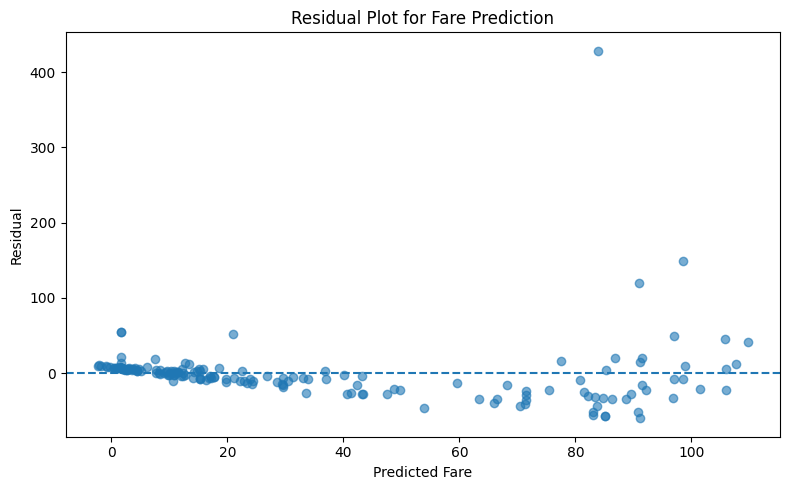

In [65]:
# Plot residuals against predicted fare.

plt.figure(figsize=(8, 5))

plt.scatter(
    fare_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Residual Plot for Fare Prediction"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()

### Task 13 Interpretation

The Linear Regression model was evaluated using MAE, RMSE, R², and Adjusted R².
MAE represents the average absolute fare prediction error, while RMSE gives greater
penalty to large prediction errors.

The residual plot is used to inspect the spread of prediction errors. If the residuals
show an uneven or widening spread as predicted fare increases, this indicates
heteroscedasticity, meaning that the error variance is not constant across predictions.

## Task 14 — Final Model Comparison and Recommendation

The classification models are compared using accuracy, precision, recall, F1-score,
and ROC-AUC. The regression model is evaluated separately using MAE, RMSE, R²,
and Adjusted R² because classification and regression metrics represent different
types of model performance.

# Create classification comparison table

In [66]:
# Final classification comparison table.

final_classification_comparison_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": logistic_results["accuracy"],
        "precision": logistic_results["precision"],
        "recall": logistic_results["recall"],
        "f1_score": logistic_results["f1_score"],
        "roc_auc": logistic_results["roc_auc"]
    },
    {
        "model": "Decision Tree",
        "accuracy": decision_tree_results["accuracy"],
        "precision": decision_tree_results["precision"],
        "recall": decision_tree_results["recall"],
        "f1_score": decision_tree_results["f1_score"],
        "roc_auc": decision_tree_results["roc_auc"]
    },
    {
        "model": "Random Forest",
        "accuracy": random_forest_results["accuracy"],
        "precision": random_forest_results["precision"],
        "recall": random_forest_results["recall"],
        "f1_score": random_forest_results["f1_score"],
        "roc_auc": random_forest_results["roc_auc"]
    },
    {
        "model": "Tuned Random Forest",
        "accuracy": tuned_rf_accuracy,
        "precision": tuned_rf_precision,
        "recall": tuned_rf_recall,
        "f1_score": tuned_rf_f1,
        "roc_auc": tuned_rf_auc
    }
])

display(
    final_classification_comparison_df.round(4)
)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8596
1,Decision Tree,0.7528,0.6714,0.6912,0.6812,0.7333
2,Random Forest,0.8090,0.7931,0.6765,0.7302,0.8243
3,Tuned Random Forest,0.7978,0.7667,0.6765,0.7188,0.8170


# Create regression comparison table

In [67]:
# Final regression metrics table.

final_regression_comparison_df = pd.DataFrame({
    "model": ["Linear Regression"],
    "MAE": [reg_mae],
    "RMSE": [reg_rmse],
    "R2": [reg_r2],
    "Adjusted_R2": [adjusted_r2]
})

display(
    final_regression_comparison_df.round(4)
)

,model,MAE,RMSE,R2,Adjusted_R2
0,Linear Regression,17.8521,40.5484,0.3837,0.3429


# Automatically identify best classifier

In [68]:
# Identify strongest classifier using ROC-AUC and F1.

best_auc_model = (
    final_classification_comparison_df
    .loc[
        final_classification_comparison_df[
            "roc_auc"
        ].idxmax()
    ]
)

best_f1_model = (
    final_classification_comparison_df
    .loc[
        final_classification_comparison_df[
            "f1_score"
        ].idxmax()
    ]
)

print("FINAL CLASSIFIER REVIEW")
print("-" * 60)

print(
    f"Best ROC-AUC: "
    f"{best_auc_model['model']} "
    f"({best_auc_model['roc_auc']:.4f})"
)

print(
    f"Best F1-score: "
    f"{best_f1_model['model']} "
    f"({best_f1_model['f1_score']:.4f})"
)

FINAL CLASSIFIER REVIEW
------------------------------------------------------------
Best ROC-AUC: Logistic Regression (0.8596)
Best F1-score: Logistic Regression (0.7402)


# Deployment recommendation

### Final Recommendation

Among the baseline classifiers, Logistic Regression achieved the strongest overall
performance, with an accuracy of 0.8146, precision of 0.7966, recall of 0.6912,
F1-score of 0.7402, and ROC-AUC of 0.8596.

The imbalance-handling experiments did not improve the F1-score beyond the baseline
Logistic Regression result. Therefore, Logistic Regression is recommended as the
preferred classifier because it provides strong predictive performance while remaining
simpler and more interpretable than the tree-based alternatives.

The Linear Regression fare model achieved an R² of 0.3837 and Adjusted R² of 0.3429.
Its residual plot also showed heteroscedasticity, so the fare regression model should be
treated as an exploratory side-task rather than a production-quality fare prediction model.

In [69]:
print("Best parameters:")
print(rf_grid_search.best_params_)

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}


## Task 15 — Save and Reload the Complete Modeling Pipeline

The selected final classifier is saved together with all preprocessing steps as one
fitted scikit-learn Pipeline. This allows the saved model to accept raw passenger
features directly without requiring separate manual preprocessing before prediction.

The saved artifact is reloaded and tested on raw input to verify that it remains usable
end to end.

# Save complete pipeline

In [70]:
# Save the complete fitted pipeline.

final_pipeline = logistic_pipeline

model_filename = "best_model_pipeline.joblib"

joblib.dump(
    final_pipeline,
    model_filename
)

print(
    f"Complete fitted pipeline saved as "
    f"{model_filename}"
)

Complete fitted pipeline saved as best_model_pipeline.joblib


# Verify file exists

In [71]:
# Verify saved model artifact exists.

print(
    "Pipeline file exists:",
    os.path.exists(
        "best_model_pipeline.joblib"
    )
)

Pipeline file exists: True


# Reload model

In [72]:
# Reload saved pipeline.

loaded_pipeline = joblib.load(
    "best_model_pipeline.joblib"
)

print(
    "Saved pipeline reloaded successfully."
)

Saved pipeline reloaded successfully.


# Test with RAW input

In [76]:
# Create one raw passenger example.

raw_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [28.0],
    "sibsp": [0],
    "parch": [0],
    "fare": [7.90],
    "embarked": ["S"]
})

display(raw_passenger)

,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,28.0,0,0,7.9,S


# Predict using reloaded pipeline

In [77]:
# Predict directly from raw input.

raw_prediction = loaded_pipeline.predict(
    raw_passenger
)

raw_probability = loaded_pipeline.predict_proba(
    raw_passenger
)[:, 1]

print(
    "Predicted survival class:",
    int(raw_prediction[0])
)

print(
    "Predicted survival probability:",
    f"{raw_probability[0]:.4f}"
)

Predicted survival class: 0
Predicted survival probability: 0.0957


# Compare original and reloaded pipeline

In [78]:
# Verify reloaded pipeline produces identical predictions.

original_predictions = final_pipeline.predict(
    X_test
)

reloaded_predictions = loaded_pipeline.predict(
    X_test
)

predictions_match = np.array_equal(
    original_predictions,
    reloaded_predictions
)

print(
    "Original and reloaded predictions match:",
    predictions_match
)

Original and reloaded predictions match: True


# Final modeling verification

In [79]:
print("=" * 65)
print("MODULE 2 MODELING VERIFICATION")
print("=" * 65)

print(
    "Train/Test split completed:",
    len(X_train) > 0 and len(X_test) > 0
)

print(
    "Three classifiers trained:",
    True
)

print(
    "GridSearchCV completed:",
    hasattr(
        rf_grid_search,
        "best_params_"
    )
)

print(
    "OOB score available:",
    hasattr(
        best_rf_classifier,
        "oob_score_"
    )
)

print(
    "Regression completed:",
    len(fare_predictions) == len(y_reg_test)
)

print(
    "Saved pipeline exists:",
    os.path.exists(
        "best_model_pipeline.joblib"
    )
)

print(
    "Reloaded predictions match:",
    predictions_match
)

print("=" * 65)
print("TASKS 7-15 COMPLETED")
print("=" * 65)

MODULE 2 MODELING VERIFICATION
Train/Test split completed: True
Three classifiers trained: True
GridSearchCV completed: True
OOB score available: True
Regression completed: True
Saved pipeline exists: True
Reloaded predictions match: True
TASKS 7-15 COMPLETED


# Mount Google Drive

In [91]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Check the real Drive folders

# Verify the Drive folder

In [93]:
!ls -la "/content/drive/MyDrive"

total 136602
-rw------- 1 root root   40648 Jun  5  2016  1016144_165931780254374_1625000317_n.jpg
-rw------- 1 root root   22288 Jun  5  2016  10450343_332884416892442_57987986767213833_n.jpg
-rw------- 1 root root   73961 Jun  5  2016  10677_598084130333535_428789267226424393_n.jpg
-rw------- 1 root root  160271 Jun  5  2016  10945009_381133365400880_3041178662994069118_n.jpg
-rw------- 1 root root   55440 Jun  5  2016  11011071_429109057269977_1980940526100053879_n.jpg
-rw------- 1 root root   38140 Jun  5  2016  11063732_429109080603308_5812961746502946732_n.jpg
-rw------- 1 root root   79125 Jun  5  2016  11205108_429109107269972_7551498969718884599_n.jpg
-rw------- 1 root root   11922 Jun  5  2016  13.jpg
-rw------- 1 root root  188841 Jun  5  2016  1417766_220084858172399_582942270_o.jpg
-rw------- 1 root root  122129 Jun  5  2016  1465963_220296361484582_472989699_o.jpg
-rw------- 1 root root   63033 Jun  5  2016  1559311_334848663362684_4959853584753427147_o.jpg
-rw------- 1 r

In [94]:
!ls -la "/content/drive/MyDrive/Colab Notebooks"

total 6035
-rw------- 1 root root 477916 Aug 11 08:04  01_data_pipeline.ipynb
-rw------- 1 root root 538057 Aug 11 09:19  01_eda.ipynb.ipynb
-rw------- 1 root root 390789 Aug 11 09:46  02_modeling.ipynb
-rw------- 1 root root  48128 Feb 14 17:20 '1.3 Masai Python Testing'
-rw------- 1 root root    367 Jun  2 05:48 '9 (1).2_data_prep_messy_data.ipynb'
-rw------- 1 root root 171086 Jun  3 14:41 '9.2_data_prep_messy_data AIML B25 PRCTC.ipynb'
-rw------- 1 root root 244039 Jun  2 09:08  9.2_data_prep_messy_data.ipynb
-rw------- 1 root root  25218 Mar  6 15:16 'Academic session 2 - Matplotlib: Basic Plotting Lectureipynb.ipynb'
-rw------- 1 root root  10907 Mar 24 11:02 'Acdemic Session Json 1.ipynb'
-rw------- 1 root root  73650 Apr 18 12:15 'Advanced Storytelling with Data - Objective Prctc.ipynb'
-rw------- 1 root root 117474 Apr 21 13:08 'Advanced Storytelling with Data - Subjective Assignment.ipynb'
-rw------- 1 root root 117263 Apr 21 12:20 'Advanced Storytelling with Data - Subjectiv

In [96]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/best_model_pipeline.joblib"

-rw------- 1 root root 4.7K Aug 11 09:39 '/content/drive/MyDrive/Colab Notebooks/best_model_pipeline.joblib'


In [97]:
%cd /content

/content


In [98]:
!git clone https://github.com/sepurkrishna4-lgtm/Zepto-Data-AI-Platform.git

Cloning into 'Zepto-Data-AI-Platform'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 76 (delta 31), reused 33 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 94.52 KiB | 1.41 MiB/s, done.
Resolving deltas: 100% (31/31), done.


# Enter the repository

In [100]:
%cd /content/Zepto-Data-AI-Platform

/content/Zepto-Data-AI-Platform


In [101]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


# Create the Module 2 branch

In [102]:
!git switch -c feature/analytics-pipeline

Switched to a new branch 'feature/analytics-pipeline'


In [103]:
!git branch

* feature/analytics-pipeline
  main


# Create the analytics folder in this fresh clone

In [104]:
!mkdir -p analytics

In [105]:
!ls

analytics  data_pipeline  README.md  support_assistant


# Copy all four Module 2 files from Google Drive

In [106]:
!cp "/content/drive/MyDrive/Colab Notebooks/01_eda.ipynb.ipynb" \
"analytics/01_eda.ipynb"